This example is from section 17.5 of Press et al., "Numerical Recipes" 4th 2017

"Stiffness typically occurs in a problem where there are two or more very different scales of the independent variable [e.g., time] on which the dependent variables are changing".

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def model(t, state):
  u,v = state

  dudt = 998*u + 1998*v
  dvdt = -999*u - 1999*v

  return dudt, dvdt

In [13]:
def exact_solution(t):
  return (2*np.exp(-t) - np.exp(-1000*t),
          -np.exp(-t)  + np.exp(-1000*t)
          )

In [14]:
state_initial = 1, 0

tspan = 0, 1

sol_rk45 = solve_ivp(model, tspan, state_initial, method='RK45')
sol_bdf = solve_ivp(model,  tspan, state_initial, method='BDF')

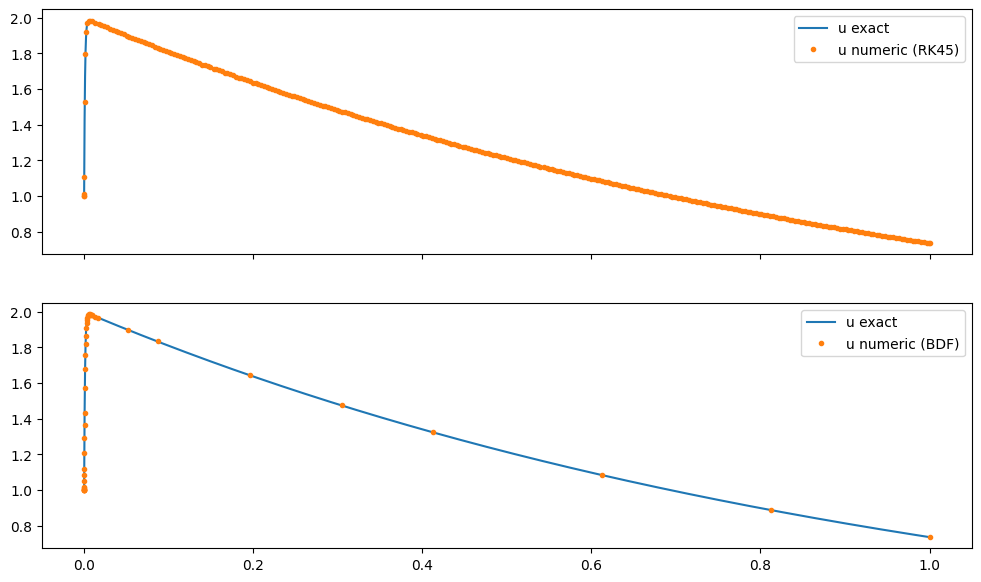

In [19]:
f, (ax, ax1) = plt.subplots(2,1,figsize=(12,7), sharex=True)

t_exact = np.linspace(tspan[0], tspan[1], 100000)

ax.plot(t_exact, exact_solution(t_exact)[0], label='u exact')
ax.plot(sol_rk45.t, sol_rk45.y[0], '.', label='u numeric (RK45)')

ax1.plot(t_exact, exact_solution(t_exact)[0], label='u exact')
ax1.plot(sol_bdf.t, sol_bdf.y[0], '.', label='u numeric (BDF)')

ax.legend()
ax1.legend()

# ax.set_xlim(-0.0001, 0.0001)
# ax.set_ylim(0.9,1.1)